## NEP_Expansion

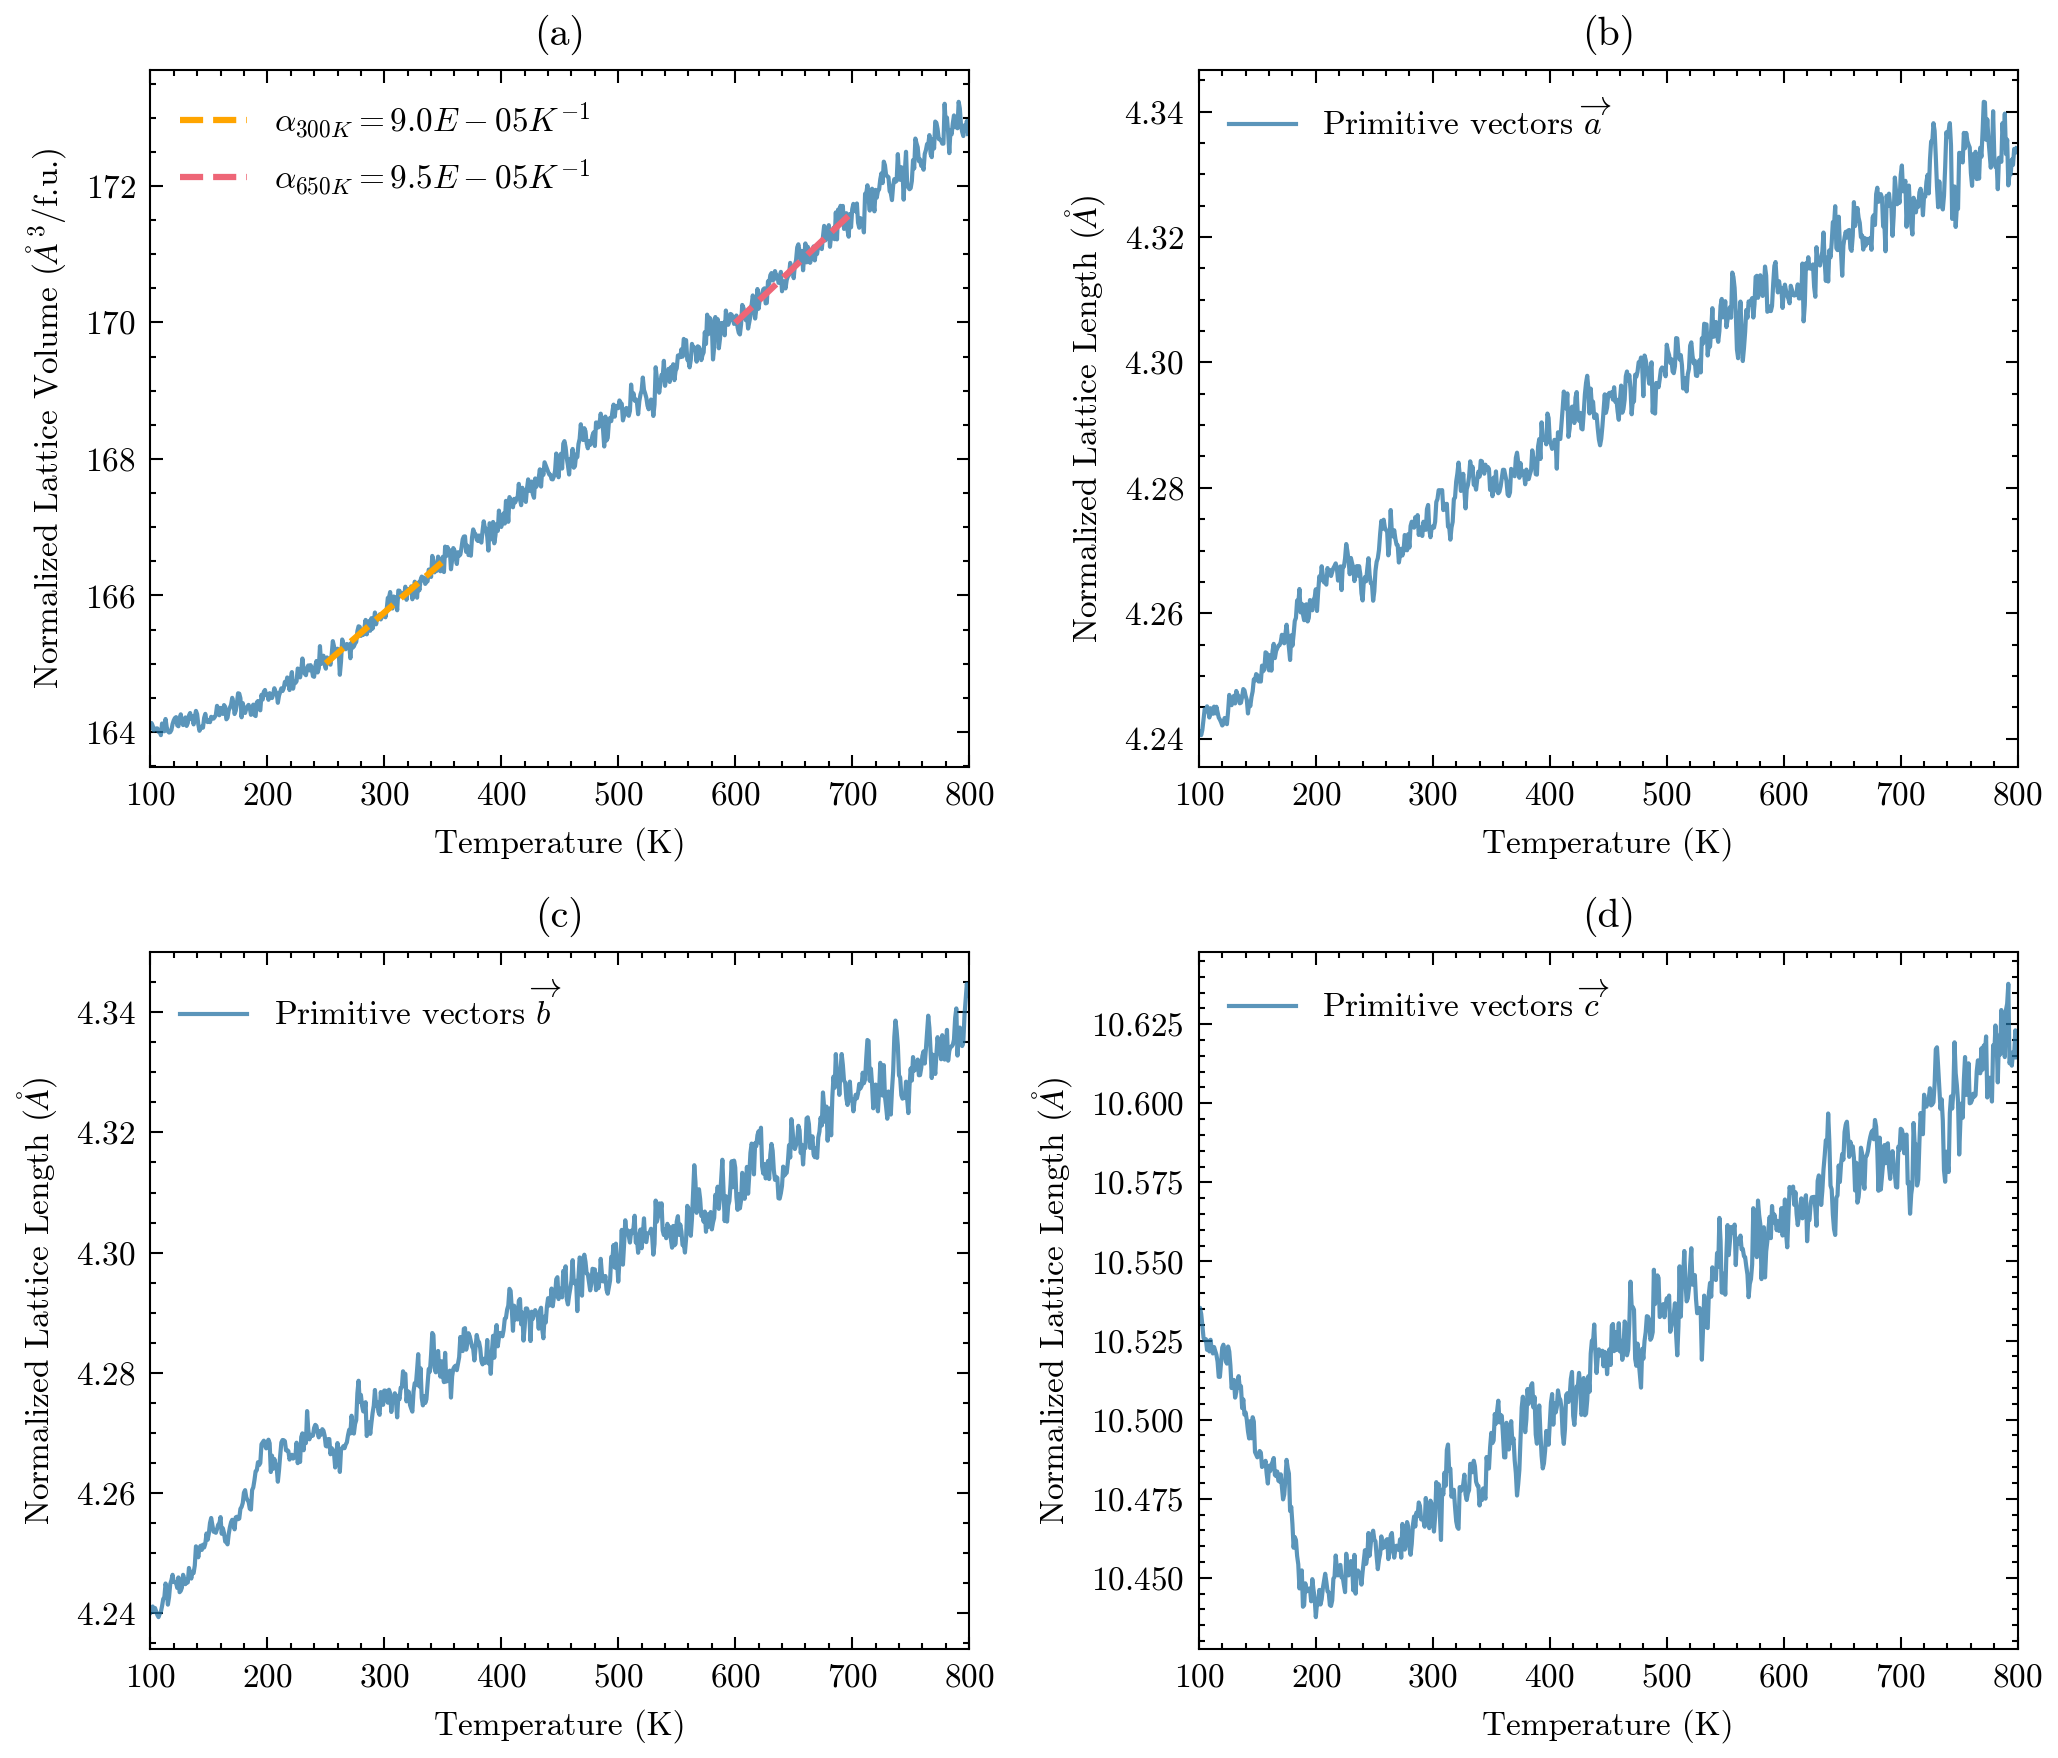

In [2]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(['science','ieee','no-latex', 'bright'])

def volume(a, b, c, n):
    arr = np.array([a, b, c]).T
    return np.linalg.det(arr) / n

def length(vec, n):
    return np.linalg.norm(vec) / n

def angle(vec1, vec2):
    cos_theta = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    angle_radians = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    return np.degrees(angle_radians)

def plot_md(filename):
    data = np.loadtxt(filename)
    cols = ["T", "K", "U", "Px", "Py", "Pz", "Pyz", "Pxz", "Pxy", 
            "ax", "ay", "az", "bx", "by", "bz", "cx", "cy", "cz"]
    thermo = pd.DataFrame(data, columns=cols)
    
    ncell = 17 * 17 * 7
    natom = (ncell) * 6
    temp = np.arange(100, 800, 1)
    interval = int(len(thermo) / len(temp))
    thermo = thermo[::interval].reset_index(drop=True)
    
    v_ave = np.array([
        volume(thermo.loc[i, ['ax', 'ay', 'az']], 
               thermo.loc[i, ['bx', 'by', 'bz']], 
               thermo.loc[i, ['cx', 'cy', 'cz']], ncell)
        for i in range(len(thermo))
    ])
    
    a_ave = np.array([length(thermo.loc[i, ['ax', 'ay', 'az']], 17) for i in range(len(thermo))])
    b_ave = np.array([length(thermo.loc[i, ['bx', 'by', 'bz']], 17) for i in range(len(thermo))])
    c_ave = np.array([length(thermo.loc[i, ['cx', 'cy', 'cz']], 7) for i in range(len(thermo))])
    
    alpha = np.array([angle(thermo.loc[i, ['bx', 'by', 'bz']], thermo.loc[i, ['cx', 'cy', 'cz']]) for i in range(len(thermo))])
    beta = np.array([angle(thermo.loc[i, ['ax', 'ay', 'az']], thermo.loc[i, ['cx', 'cy', 'cz']]) for i in range(len(thermo))])
    gamma = np.array([angle(thermo.loc[i, ['ax', 'ay', 'az']], thermo.loc[i, ['bx', 'by', 'bz']]) for i in range(len(thermo))])
    
    # p_ave = thermo[['Px', 'Py', 'Pz', 'Pyz', 'Pxz', 'Pxy']].mean(axis=1)
    # tot_ene = (thermo['K'] + thermo['U']) / natom
    
    # 创建图表
    plt.figure(figsize=(7, 6), dpi=300)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    plt.subplot(2, 2, 1)
    plt.plot(temp, v_ave, color="#2472A3", alpha=0.75)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(temp[150:250], v_ave[150:250])
    fit_line = slope * temp[150:250] + intercept
    coeff = slope / v_ave[200]
    plt.plot(temp[150:250], fit_line, color="orange", label=f"$\\alpha_{{300K}} = {coeff:.1E} K^{{-1}}$", ls='--', lw=1.5)
    slope, intercept, r_value, p_value, std_err = stats.linregress(temp[500:600], v_ave[500:600])
    fit_line = slope * temp[500:600] + intercept
    coeff = slope / v_ave[550]
    plt.plot(temp[500:600], fit_line, color='#EE6677', label=f"$\\alpha_{{650K}} = {coeff:.1E} K^{{-1}}$", ls='--', lw=1.5)
    
    plt.xlim(100, 800)
    plt.xlabel('Temperature (K)')
    plt.ylabel('Normalized Lattice Volume ($Å^3$/f.u.)')
    plt.xticks(np.arange(100, 850, 100))
    plt.legend(loc="best")
    plt.title('(a)')
    
    plt.subplot(2, 2, 2)
    plt.plot(temp, a_ave, color="#2472A3", alpha=0.75, label=r'Primitive vectors $\overrightarrow{a}$')
    plt.xlim(100, 800)
    plt.xlabel('Temperature (K)')
    plt.ylabel('Normalized Lattice Length ($Å$)')
    plt.xticks(np.arange(100, 850, 100))
    plt.legend(loc="best")
    plt.title('(b)')
    
    plt.subplot(2, 2, 3)
    plt.plot(temp, b_ave, color="#2472A3", alpha=0.75, label=r'Primitive vectors $\overrightarrow{b}$')
    plt.xlim(100, 800)
    plt.xlabel('Temperature (K)')
    plt.ylabel('Normalized Lattice Length ($Å$)')
    plt.xticks(np.arange(100, 850, 100))
    plt.legend(loc="best")
    plt.title('(c)')
    
    plt.subplot(2, 2, 4)
    plt.plot(temp, c_ave, color="#2472A3", alpha=0.75, label=r'Primitive vectors $\overrightarrow{c}$')
    plt.xlim(100, 800)
    plt.xlabel('Temperature (K)')
    plt.ylabel('Normalized Lattice Length ($Å$)')
    plt.xticks(np.arange(100, 850, 100))
    plt.legend(loc="best")
    plt.title('(d)')
    
    plt.tight_layout()
    plt.savefig('./Ge0.9Te1.1/lattice_expansion_D3.png', bbox_inches='tight')

plot_md('./Ge0.9Te1.1/thermo_d3.out')

The volume thermal-expansion coefficient of the rhombohedral GeTe equals 4.59 × 10−5 K−1 at 300 K, whereas it amounts to 7.67 × 10−5 K−1 at 650 K for the cubic GeTe. [Anomalous temperature-induced volume contraction in GeTe]